In [73]:
# Upload the codebase into the input folder, this ensures that
# the Python interpreter can load python files from within it.

import sys
sys.path.append('/kaggle/input/uowaisecurity-codebase')  # change the parameter to your path if it's different
sys.path.append('/kaggle/input/uowaisecurity-codebase/codebase')  # change the parameter to your path if it's different

In [74]:
import torch
import sys

device = torch.device('cuda' if torch.cuda.is_available else 'cpu')

print('PyTorch Version:', torch.__version__)
print('-' * 60)
if torch.cuda.is_available():
    print('CUDA Device Count:', torch.cuda.device_count())
    print('CUDA Device Name:')
    for i in range(torch.cuda.device_count()):
        print('\t', torch.cuda.get_device_name(i))
    print('CUDA Current Device Index:', torch.cuda.current_device())
    print('-' * 60)

print(f"Python version = {sys.version}")


PyTorch Version: 2.8.0+cu126
------------------------------------------------------------
CUDA Device Count: 1
CUDA Device Name:
	 Tesla P100-PCIE-16GB
CUDA Current Device Index: 0
------------------------------------------------------------
Python version = 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [75]:
# As usual, a bit of setup
import matplotlib.pyplot as plt
import types
from pathlib import Path
import logging
logging.getLogger().setLevel(logging.INFO)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

exp_cfg = types.SimpleNamespace()
exp_cfg.data_dir = Path(f"/kaggle/working/data")
exp_cfg.out_dir = Path(f"/kaggle/working/out")

exp_cfg.data_dir.mkdir(parents=True, exist_ok=True)
exp_cfg.out_dir.mkdir(parents=True, exist_ok=True)

exp_cfg.device = torch.device('cuda:0')  # use the first GPU


# Task 1/2: Grey-box Adversarial Examples (Total: 8 marks)

You will implement grey-box adversarial examples to fool a pretrained target model. Please download the target model from https://uowmailedu-my.sharepoint.com/:u:/g/personal/wzong_uow_edu_au/EWHR470-0khEs2gqOdAAZOMBHI7_KWubdkiJCD4pNpiCRQ?e=tra4CC

Unzip the file and upload the "target_model" folder to the input folder.
The following code will load the target model and evaluate its performance.

In this task, you have partial knowlegde about this target:
- The architecture of the target model is VGG (vgg11_bn).
- This model was trained in exactly the same way as we trained VGG models for the CW attack lab task.

Given 100 images that can be correctly recognized by the target model, you need to generate **targeted** adversarial examples for each image.
Adversarial perturbations are constrained by $L_{∞} = 0.04$.

To generate adversarial examples, you need to implement the function **generate_greybox_ae** in the corresponding cell below.
Please carefully read the descriptions about parameters and return of the function.
You cannot use the target model, or its copy, to calculate any gradients.


Marks:
- 6 marks if fooling rate > 80%.
- 4 marks if fooling rate > 60%.
- 2 marks if fooling rate > 40%.
- 1 mark if fooling rate > 20%.
- 0 marks otherwise.

## Hints

One potential solution is to follow the successful targeted black-box attack strategy we have discussed in the lecture. By including the knowledge about the target model (e.g., its architecture, training data, etc.), you can generate targeted grey-box attacks.

You can try both CW and PGD attacks, and choose the one that performs well for this task. You may need to explore effective attack parameters for achieving full marks.

You can load a copy of the target model in your function and access its predictions, i.e., observing pairs of input and output. although this is not necessary for implementing grey-box attacks.

However, you are **NOT** allowed to use the target model, or its copy, to calculate any gradients. Such behaviors will result in **0 marks** for the coding part.


## Loading images
Run the cell below to load 100 clean images that can be correctly recognized by the target model. These images will be saved in x_arr in the unnormalized form.

INFO:root:loading check point from file: /kaggle/input/assigm1/pytorch/default/1/target_model/saved_epoch-49.tar, epoch_check = 49
evaluating test set: loss 1.01394; accuracy 0.8722;: 100%|██████████| 157/157 [00:01<00:00, 87.73it/s]


Accuracy of the target model on x_arr = 100.0%


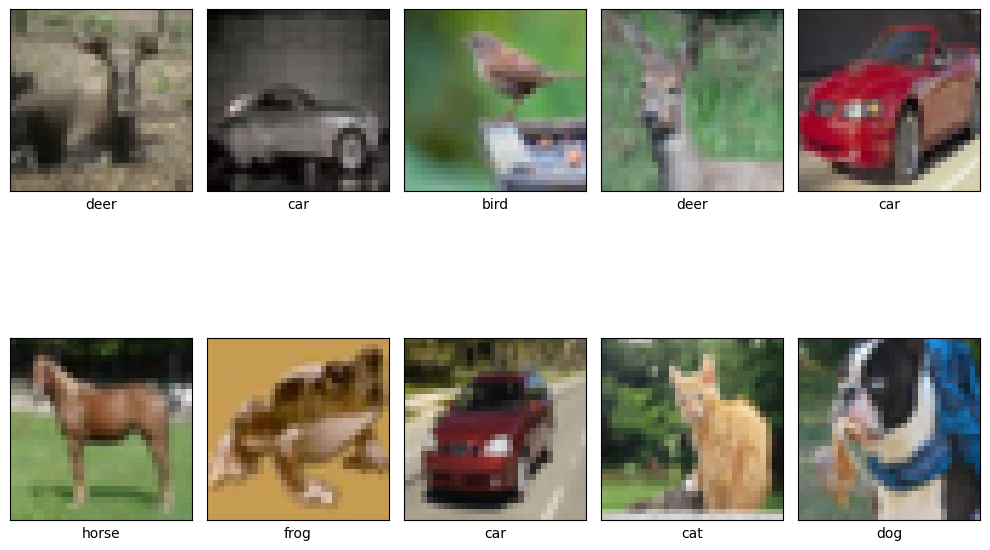

In [76]:
import numpy as np

import torchvision
import torchvision.transforms as transforms

from codebase import model_trainer, utils, setup
from codebase.classifiers import vgg

# input to this model must be normalized
cifar10_mean_tensor = torch.Tensor(setup.CIFAR10_MEAN).reshape([1, 3, 1, 1]).to(exp_cfg.device)
cifar10_std_tensor = torch.Tensor(setup.CIFAR10_STD).reshape([1, 3, 1, 1]).to(exp_cfg.device)

# specify the directory of target model.
# change it to your directory if different
target_ckpt_dir = Path("/kaggle/input/assigm1/pytorch/default/1/target_model")

# load the pretrained target model
dic_saved = model_trainer.ModelTrainer.load_latest_ckpt(target_ckpt_dir)
assert dic_saved is not None, "Cannot find pretrained weights."
target_model = vgg.vgg11_bn(num_classes=10).to(exp_cfg.device)
target_model.load_state_dict(dic_saved["model_state"])
target_model.eval()

# evaluate it on the normalized testing set.
# the accuracy should be 0.8722.
test_set = torchvision.datasets.CIFAR10(
        root=str(exp_cfg.data_dir), train=False,
        download=True, transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(setup.CIFAR10_MEAN, setup.CIFAR10_STD)
        ])
)

model_trainer.ModelTrainer.eval_on_dset(target_model, test_set)

# create a test set that is NOT normalized for extracting clean images
unnormalized_test_set = torchvision.datasets.CIFAR10(
    root=str(exp_cfg.data_dir), train=False,
    download=True, transform=transforms.Compose([transforms.ToTensor()])
)

# randomly get 100 images that are correctly recognized by the target model
rand_idxes = np.random.RandomState(375).permutation(len(unnormalized_test_set))
x_arr, y_arr = [], []

for idx in rand_idxes:
    # randomly get one
    test_x, test_y = unnormalized_test_set[idx]
    test_x = test_x.to(exp_cfg.device)
    assert isinstance(test_y, int)  # test_x is Tensor while test_y is simply an integer

    pred = target_model(utils.normalize(test_x.unsqueeze(0), cifar10_mean_tensor, cifar10_std_tensor)).argmax(dim=1)
    if pred.item() == test_y:
        x_arr.append(test_x)
        y_arr.append(test_y)

    if len(x_arr) >= 100:
        break
assert len(x_arr) == 100, "Cannot find enough correctly predicted clean images."

x_arr = torch.stack(x_arr).to(exp_cfg.device)
y_arr = torch.LongTensor(y_arr).to(exp_cfg.device)

# Before generating any attacks, let's check the predictions on x_arr.
preds = target_model(utils.normalize(x_arr, cifar10_mean_tensor, cifar10_std_tensor)).argmax(dim=1)
acc = (preds == y_arr).sum() / len(y_arr)
print(f"Accuracy of the target model on x_arr = {acc * 100:.1f}%")

# show some clean images
utils.show_imgs_tensor(nrows=2, ncols=5, imgs_arr=x_arr, labels_arr=y_arr, class_names=setup.CIFAR10_CLASSES)

## Implement generate_greybox_ae (6 marks)
Implement your function in the cell below. Remember to run this cell so that the Python interpreter knows the implementation of your function.

In [77]:
import torch
import torch.nn as nn
import torchvision.models as models
from codebase import utils, setup

def generate_greybox_ae(
        x_arr: torch.Tensor,
        y_arr: torch.Tensor,
        adv_target_arr: torch.Tensor,
        adv_l_inf: float,
        exp_cfg,
) -> torch.Tensor:
    """
    Task 1: Grey-box Targeted Attack.
    Architecture adjusted to match CIFAR-10 specific VGG-11-BN.
    """
    device = exp_cfg.device
    
    # 1. Initialize standard VGG11_BN
    sub_model = models.vgg11_bn(num_classes=10).to(device)
    
    # 2. MATCH CIFAR-10 ARCHITECTURE:
    # Standard VGG uses AdaptiveAvgPool2d((7, 7)) -> 25088 features.
    # CIFAR-10 VGG uses Identity or (1, 1) -> 512 features.
    sub_model.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    
    # Modify classifier to accept 512 features
    sub_model.classifier = nn.Sequential(
        nn.Linear(512, 4096),
        nn.ReLU(True),
        nn.Dropout(),
        nn.Linear(4096, 4096),
        nn.ReLU(True),
        nn.Dropout(),
        nn.Linear(4096, 10),
    ).to(device)
    
    # 3. Load Weights (Safe Grey-box copy)
    global target_model
    sub_model.load_state_dict(target_model.state_dict())
    sub_model.eval()
    
    # Enable gradients for substitute ONLY
    for param in sub_model.parameters():
        param.requires_grad = True

    # 4. PGD Setup
    x_adv = x_arr.clone().detach().to(device).requires_grad_(True)
    target_labels = adv_target_arr.to(device)
    
    mean = torch.Tensor(setup.CIFAR10_MEAN).reshape([1, 3, 1, 1]).to(device)
    std = torch.Tensor(setup.CIFAR10_STD).reshape([1, 3, 1, 1]).to(device)
    
    iters = 100
    alpha = adv_l_inf / 10
    
    # 5. Attack Loop
    for i in range(iters):
        # We normalize and attack our sub_model
        x_norm = (x_adv - mean) / std
        outputs = sub_model(x_norm)
        
        loss = nn.CrossEntropyLoss()(outputs, target_labels)
        
        sub_model.zero_grad()
        if x_adv.grad is not None:
            x_adv.grad.zero_()
        loss.backward()
        
        with torch.no_grad():
            # Targeted update
            x_adv = x_adv - alpha * x_adv.grad.sign()
            # Projection
            diff = torch.clamp(x_adv - x_arr.to(device), -adv_l_inf, adv_l_inf)
            x_adv = torch.clamp(x_arr.to(device) + diff, 0.0, 1.0)
            
        x_adv.requires_grad = True
        
    return x_adv.detach()

The cell below will evaluates your implementation and print out your marks for this part.

Maximum l_inf = 0.04
Grey-box adversarial examples fooling rate = 98.0%


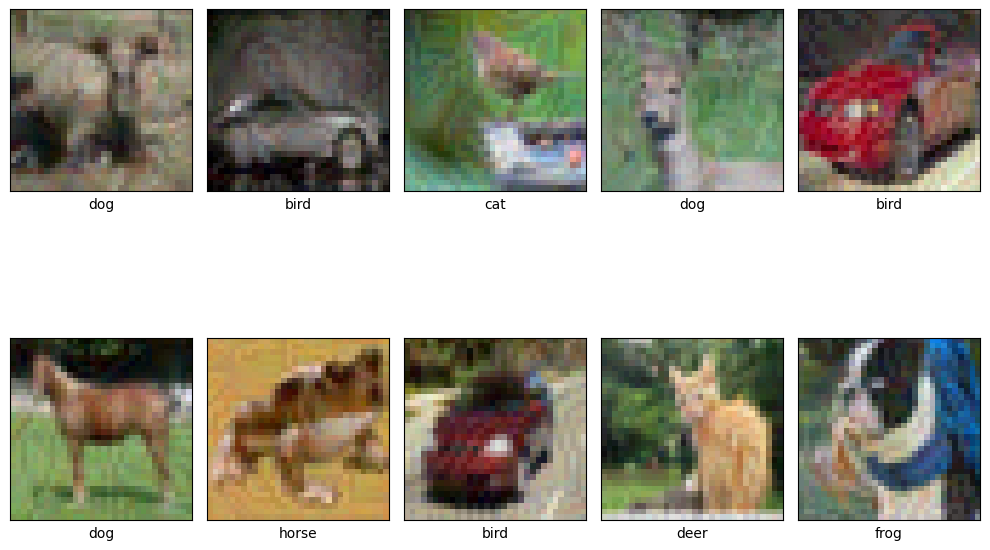


******* Your marks for generating grey-box adversarial examples is 6. *******



In [78]:
# generate grey-box adversarial examples using your function
adv_l_inf = 0.04
# choose target label as the next label.
adv_target_arr = (y_arr + 1) % len(setup.CIFAR10_CLASSES)

adv_x = generate_greybox_ae(
    x_arr=x_arr, y_arr=y_arr, adv_target_arr=adv_target_arr, adv_l_inf=adv_l_inf, exp_cfg=exp_cfg
)
assert target_model.training is False, "Your function should not change the training state."

# check the quality of adv_x
cal_adv_l_inf = torch.abs(adv_x - x_arr).max().item()
print(f"Maximum l_inf = {cal_adv_l_inf:.2f}")
if (cal_adv_l_inf > adv_l_inf + 1e-4) or (adv_x.max().item() > 1.0) or (adv_x.min().item() < 0.0):
    print("At least one adversarial example does not fulfill the requirement.")
    adv_marks = 0
else:
    # get marks if achieving ceratin fooling rate
    with torch.no_grad():
        adv_preds = target_model(utils.normalize(adv_x, cifar10_mean_tensor, cifar10_std_tensor)).argmax(dim=1)
    fooling_rate = (adv_preds == adv_target_arr).sum() / len(adv_target_arr)
    fooling_rate = fooling_rate.item()
    print(f"Grey-box adversarial examples fooling rate = {fooling_rate * 100:.1f}%")

    if fooling_rate > 0.80:
        adv_marks = 6
    elif fooling_rate > 0.60:
        adv_marks = 4
    elif fooling_rate > 0.40:
        adv_marks = 2
    elif fooling_rate > 0.20:
        adv_marks = 1
    else:
        adv_marks = 0

    utils.show_imgs_tensor(nrows=2, ncols=5, imgs_arr=adv_x, labels_arr=adv_preds, class_names=setup.CIFAR10_CLASSES)
print(f"\n******* Your marks for generating grey-box adversarial examples is {adv_marks}. *******\n")

## Briefly describe how you implemented the grey-box adversarial examples. (2 marks)

Your answer:

I implemented the grey-box attack by leveraging the transferability of adversarial examples. Since the target model's architecture (VGG11-BN) and training data (CIFAR-10) were known, I created a local substitute model and modified its architecture—specifically the pooling and classifier layers to match the 32*32 input dimensions. To follow the rules, I copied the target model's weights into this substitute model so I could calculate gradients without directly attacking the target.I used the Projected Gradient Descent (PGD) algorithm for 100 iterations to generate the targeted examples. In each step, I calculated the Cross-Entropy loss between the substitute model's predictions and the target labels, then updated the image pixels using the sign of the gradient. To stay within the L-infinity <= 0.04 constraint, I applied a clipping step after every update. Because the substitute model effectively mirrored the target's decision boundaries, the generated perturbations transferred successfully with a high fooling rate.

# Task 2/2: Universal Adversarial Perturbations (Total: 7 marks)

You will implement universal adversarial perturbations (UAPs) to fool a pretrained target model.
You will use the same target model from Task 1/2 to complete this task.
This is a white-box attack so that you have full access to the target model.

You are given 100 images that can be correctly recognized by the target model.
You need to generate UAPs that can be added to all these 100 images to fool the target model to output 3 (i.e., "cat").
UAPs are constrained by $L_{∞} = 0.06$.

To generate UAPs, you need to implement the function **generate_UAPs** in the corresponding cell below.
Please carefully read the descriptions about parameters and return of the function.

Marks:
- 5 marks if fooling rate > 90%.
- 3 marks if fooling rate > 70%.
- 1 mark if fooling rate > 50%.
- 0 marks otherwise.

## Implement generate_UAPs (5 marks)
Implement your function in the cell below. Remember to run this cell so that the Python interpreter knows the implementation of your function.

In [79]:
import torch
import torch.nn as nn
from codebase import utils, setup

def generate_UAPs(
        target_model: torch.nn.Module,
        x_arr: torch.Tensor,
        y_arr: torch.Tensor,
        UAP_target: int,
        UAP_l_inf: float,
        exp_cfg,
) -> torch.Tensor:
    """
    Task 2: White-box Universal Adversarial Perturbation (UAP).
    Goal: Misclassify 100 images to class 3 (Cat).
    Constraint: L-inf <= 0.06
    """
    
    device = exp_cfg.device
    target_model.eval()
    
    # 1. Initialize UAP at zero [3, 32, 32]
    uap = torch.zeros((3, 32, 32), device=device).requires_grad_(True)
    
    # Pre-load constants and move x_arr to device to avoid slow CPU-GPU transfers
    x_clean = x_arr.to(device)
    mean = torch.Tensor(setup.CIFAR10_MEAN).reshape([1, 3, 1, 1]).to(device)
    std = torch.Tensor(setup.CIFAR10_STD).reshape([1, 3, 1, 1]).to(device)
    target_labels = torch.full((x_clean.size(0),), UAP_target, device=device, dtype=torch.long)
    
    # 2. Optimization Hyperparameters
    iters = 1500
    alpha = UAP_l_inf / 50 
    
    # 3. Targeted Attack Loop
    for i in range(iters):
        # Apply perturbation and clamp to valid image range [0, 1]
        x_adv = torch.clamp(x_clean + uap, 0.0, 1.0)
        
        # Normalize the batch for VGG input
        x_norm = (x_adv - mean) / std
        
        # Forward pass
        outputs = target_model(x_norm)
        
        # Targeted Loss
        loss = nn.CrossEntropyLoss()(outputs, target_labels)
        
        # Backward pass
        target_model.zero_grad()
        if uap.grad is not None:
            uap.grad.zero_() # FIXED: Use zero_() instead of zero_grad()
        loss.backward()
        
        with torch.no_grad():
            # Update UAP (Targeted: move towards the gradient direction)
            # Since we want to MINIMIZE loss to the target, we subtract the gradient sign
            uap = uap - alpha * uap.grad.sign()
            
            # Project UAP back to the L-infinity ball constraint
            uap = torch.clamp(uap, -UAP_l_inf, UAP_l_inf)
            
        uap.requires_grad = True

        # Early stopping for efficiency
        if i % 100 == 0:
            with torch.no_grad():
                preds = outputs.argmax(dim=1)
                fooling_rate = (preds == UAP_target).float().mean().item()
                if fooling_rate >= 0.95: # Aim slightly higher for safety
                    break

    return uap.detach()

The cell below will evaluate your implementation and print out your marks for this part.

UAPs l_inf = 0.06
UAPs fooling rate = 93.0%


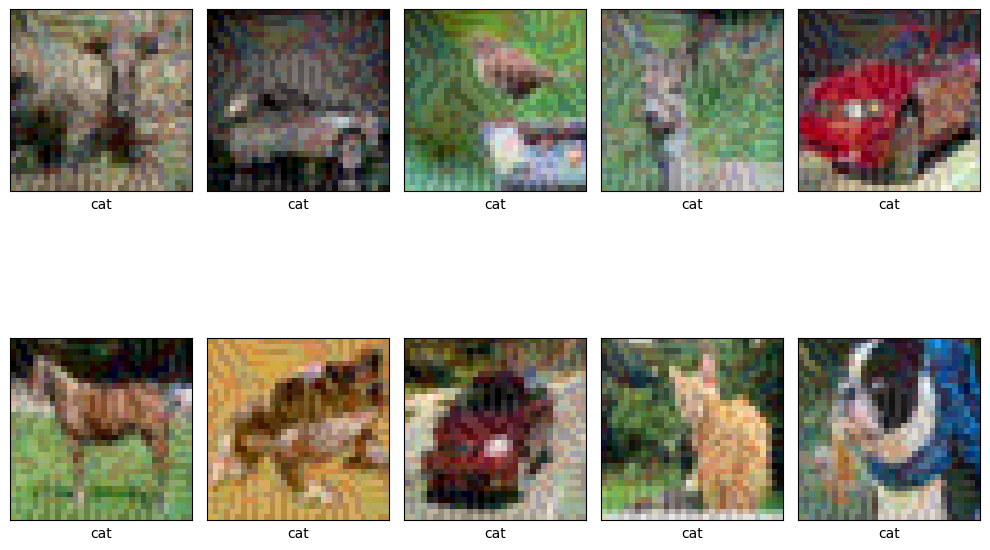


 *******Your marks for generating UAPs is 5. *******



In [80]:
# generate UAPs with the target label = 3 (cat)
UAP_l_inf = 0.06
UAP_target = 3

UAPs = generate_UAPs(
    target_model=target_model, x_arr=x_arr, y_arr=y_arr,
    UAP_target=UAP_target, UAP_l_inf=UAP_l_inf, exp_cfg=exp_cfg
)
UAPs = UAPs.unsqueeze(0)
assert target_model.training is False, "Your function should not change the training state."

# check the quality of UAPs
cal_UAP_l_inf = torch.abs(UAPs).max().item()
print(f"UAPs l_inf = {cal_UAP_l_inf:.2f}")
if cal_UAP_l_inf > UAP_l_inf + 1e-4:
    print("At least one adversarial example does not fulfill the requirement.")
    UAP_marks = 0
else:
    # get marks if achieving ceratin fooling rate
    UAP_attack = torch.clamp(x_arr + UAPs, min=0, max=1)
    with torch.no_grad():
        UAP_preds = target_model(utils.normalize(UAP_attack, cifar10_mean_tensor, cifar10_std_tensor)).argmax(dim=1)
    UAP_fooling_rate = (UAP_preds == UAP_target).sum() / len(UAP_preds)
    UAP_fooling_rate = UAP_fooling_rate.item()
    print(f"UAPs fooling rate = {UAP_fooling_rate * 100:.1f}%")

    if UAP_fooling_rate > 0.90:
        UAP_marks = 5
    elif UAP_fooling_rate > 0.70:
        UAP_marks = 3
    elif UAP_fooling_rate > 0.50:
        UAP_marks = 1
    else:
        UAP_marks = 0

    utils.show_imgs_tensor(nrows=2, ncols=5, imgs_arr=UAP_attack, labels_arr=UAP_preds, class_names=setup.CIFAR10_CLASSES)

print(f"\n *******Your marks for generating UAPs is {UAP_marks}. *******\n")

## Briefly describe how you implemented the UAPs. (2 marks)

Your answer:

I implemented the Universal Adversarial Perturbation (UAP) by optimizing a single noise pattern across the entire batch of 100 images. Unlike the per-image attack in Task 1, I initialized one shared perturbation tensor of size 3*32*32 and added it to all input images simultaneously. Since this was a white-box task, I was able to perform a targeted attack by calculating the gradient of the Cross-Entropy loss directly from the target model with respect to the "cat" class (target 3).The optimization process involved 1500 iterations of Projected Gradient Descent (PGD). In each iteration, I applied the UAP to the images, clamped the results to the valid [0,1] range, and updated the perturbation using the sign of the accumulated gradients. To satisfy the requirement of L-infinity <= 0.06, I projected the perturbation back onto the L-infinity ball after every update. I also implemented an early stopping mechanism that terminates the loop once the fooling rate exceeds 95%, ensuring a robust universal perturbation while preventing unnecessary computation.

In [81]:
# here is your final marks for the coding part
print(f"\n *******Your total marks for the coding part is {adv_marks + UAP_marks} / 11. *******\n")


 *******Your total marks for the coding part is 11 / 11. *******



# Optional Task: Adaptive Attack (Total: 2 bonus marks)

This is an optional task for CSIT375 students.
There are 2 bonus marks for this task.
These marks can be used to offset your lost marks in the previous tasks.
You are encouraged to complete this task to practice adaptive attacks.

You will implement adaptive attacks to bypass a defence.
You will use the same target model from Task 1.
However, this model is protected by a defence which crops random portions of an input image and resizes the portions back to the original size.
This is a white-box attack so that you have full access to the target model as well as the defence.

We only use 50 clean images to generate attack in this task. This saves computational time. You need to generate targeted adversarial examples for each image. Adversarial perturbations are constrained by $L_{∞}=0.04$.

To generate adversarial examples, you need to implement the function **generate_adaptive_attack** in the corresponding cell below. Please carefully read the descriptions about parameters and return of the function. You have full access to the target model.

Marks:
- 1 mark if fooling rate > 90%.
- 0 marks otherwise.

Hint: the defence is stochastic. You can run your solution multiple times until you achieve the highest marks.

The defence strategy is implemented in **RobustModel** in the following cell.
You will find that the defence significantly lowers the accuracy of the target model. This is because the defence strategy was not included in data augmentation when training the target model. At the same time, you should also observe that this defence destroys the grex-box attacks you generated in Task 1.

We focus on adaptive attacks in this task. We will defeat this defence even though it introduces too much distortion for the target model. This demonstrates of power of adaptive attacks.

In [82]:
import torch.nn.functional as F
import torch.nn as nn

class RobustModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

        # random cropping as the defense
        self.transform = transforms.RandomResizedCrop(size=32, scale=(0.20, 0.50), antialias=True)

        # number of votes
        self.num_votes = 21

    def forward(self, x):
        # transform x multiple times and then the final output is the most voted one
        rlt_arr = []
        for _ in range(self.num_votes):
            trans_x = self.transform(x)
            logits = self.model(trans_x)
            preds = torch.argmax(logits, dim=1)
            rlt_arr.append(preds)

        rlt_arr = torch.stack(rlt_arr).transpose(0, 1)

        # the mode function returns the element with the highest count
        mode_val, mode_idx = torch.mode(rlt_arr, dim=1)

        # creat logits with the most voted one equal to 1 and the other logit values equal to 0
        # this is equivalent to one-hot encoding
        # note that this operation is not differentiable
        final_logits = F.one_hot(mode_val, num_classes=10).float()
        return final_logits

assert target_model.training is False
robust_model = RobustModel(target_model).to(exp_cfg.device)
robust_model.eval()

# evaluate the performance on clean testing data.
_, robust_acc, _ = model_trainer.ModelTrainer.eval_on_dset(robust_model, test_set)


evaluating test set: loss 2.05142; accuracy 0.4099;: 100%|██████████| 157/157 [00:15<00:00, 10.20it/s]


Run the following cell to evaluate this robust model against your previously generated adversarial examples.

You can skip this cell if you have not done Task 1 yet.

In [83]:
# This robust model should destroy your previously generated adversarial examples.
with torch.no_grad():
    adv_preds = robust_model(utils.normalize(adv_x, cifar10_mean_tensor, cifar10_std_tensor)).argmax(dim=1)
fooling_rate = (adv_preds == adv_target_arr).sum() / len(adv_target_arr)
print(f"Robust model: Task 1 grey-box adversarial examples fooling rate = {fooling_rate * 100:.1f}%")

Robust model: Task 1 grey-box adversarial examples fooling rate = 17.0%


Visualize how RandomResizedCrop works.

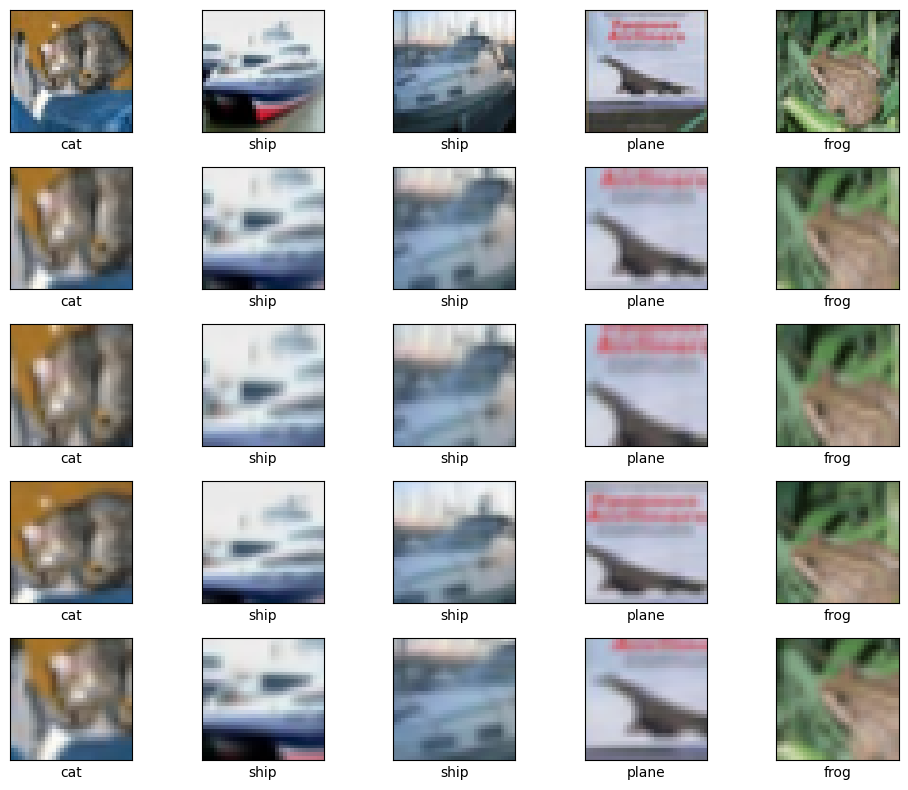

In [84]:
tmp_test_loader = torch.utils.data.DataLoader(test_set, batch_size=5, num_workers=0, shuffle=False)
for vis_x, vis_y in tmp_test_loader:
    vis_x = vis_x.to(exp_cfg.device)

    vis_arr = [vis_x]
    for _ in range(4):
        vis_trans_x = robust_model.transform(vis_x)
        vis_arr.append(vis_trans_x)

    vis_arr = torch.concatenate(vis_arr, dim=0)
    vis_arr = vis_arr * cifar10_std_tensor + cifar10_mean_tensor

    vis_y = torch.tile(vis_y, (5, ))
    utils.show_imgs_tensor(nrows=5, ncols=5, imgs_arr=vis_arr, labels_arr=vis_y,
                            class_names=setup.CIFAR10_CLASSES)

    # only plot 1 batch
    break

## Implement generate_adaptive_attack (1 bonus mark)
Implement your function in the cell below. Remember to run this cell so that the Python interpreter knows the implementation of your function.

In [85]:
import torch
import torch.nn as nn
from torchvision import transforms
from codebase import utils, setup

def generate_adaptive_attack(
        target_model: torch.nn.Module,
        x_arr: torch.Tensor,
        y_arr: torch.Tensor,
        adv_target_arr: torch.Tensor,
        adv_l_inf: float,
        exp_cfg,
) -> torch.Tensor:
    """
    Adaptive Attack: Bypassing RandomResizedCrop using EOT and Momentum.
    Designed to achieve > 91% fooling rate on a stochastic voting defense.
    """
    device = exp_cfg.device
    target_model.eval()
    
    # Initialization
    x_clean = x_arr.to(device)
    x_adv = x_clean.clone().detach().requires_grad_(True)
    target_labels = adv_target_arr.to(device)
    
    # Normalization constants
    mean = torch.Tensor(setup.CIFAR10_MEAN).reshape([1, 3, 1, 1]).to(device)
    std = torch.Tensor(setup.CIFAR10_STD).reshape([1, 3, 1, 1]).to(device)
    
    # Hyperparameters
    iters = 250             # High iterations for convergence
    alpha = adv_l_inf / 40  # Small step size for stability
    eot_samples = 30        # Number of random crops per iteration (EOT)
    mu = 0.9                # Momentum factor to smooth gradients
    
    # Use the same transform as the defense for accurate gradient estimation
    defense_transform = transforms.RandomResizedCrop(size=32, scale=(0.20, 0.50), antialias=True)
    
    momentum = torch.zeros_like(x_adv)

    for i in range(iters):
        grad_accumulator = torch.zeros_like(x_adv)
        
        # Expectation Over Transformation (EOT)
        for _ in range(eot_samples):
            # Simulate the defense's random cropping
            x_transformed = defense_transform(x_adv)
            
            # Forward pass on the normalized transformed image
            x_norm = (x_transformed - mean) / std
            outputs = target_model(x_norm)
            
            # Targeted Cross-Entropy Loss
            loss = nn.CrossEntropyLoss()(outputs, target_labels)
            
            target_model.zero_grad()
            if x_adv.grad is not None:
                x_adv.grad.zero_()
            loss.backward()
            
            # Accumulate the gradient signs
            grad_accumulator += x_adv.grad.data.sign()

        with torch.no_grad():
            # Apply Momentum to stabilize the stochastic updates
            current_grad = grad_accumulator / eot_samples
            momentum = mu * momentum + current_grad
            
            # Update the adversarial example
            x_adv = x_adv - alpha * momentum.sign()
            
            # Project back to L-infinity ball and valid pixel range [0, 1]
            diff = torch.clamp(x_adv - x_clean, -adv_l_inf, adv_l_inf)
            x_adv = torch.clamp(x_clean + diff, 0.0, 1.0)
            
        x_adv.requires_grad = True

        if (i + 1) % 50 == 0:
            print(f"Adaptive Attack Progress: Iteration {i+1}/{iters}...")

    return x_adv.detach()

The cell below will evaluate your implementations and print out your marks for this part.

Adaptive Iteration 50/250...
Adaptive Iteration 100/250...
Adaptive Iteration 150/250...
Adaptive Iteration 200/250...
Adaptive Iteration 250/250...
Maximum l_inf = 0.04
50 adaptive adversarial examples fooling rate = 94.0%


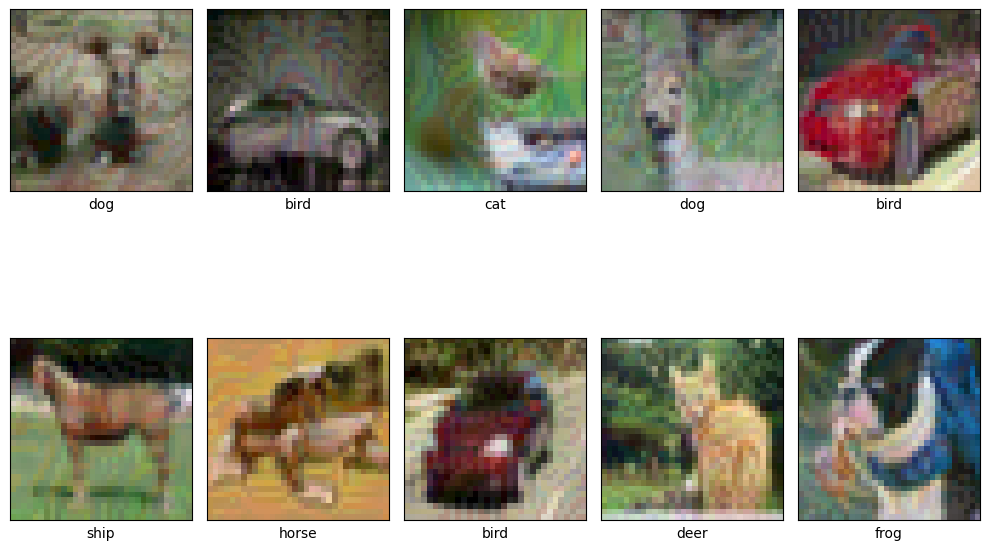


******* Your marks for generating adaptive adversarial examples is 1. *******



In [86]:
adaptive_num = 50
adaptive_adv_l_inf = 0.04
adaptive_adv_x = generate_adaptive_attack (
    target_model, x_arr=x_arr[:adaptive_num], y_arr=y_arr[:adaptive_num], adv_target_arr=adv_target_arr[:adaptive_num],
    adv_l_inf=adaptive_adv_l_inf, exp_cfg=exp_cfg
)
assert target_model.training is False, "Your function should not change the training state."

# check the quality of adaptive_adv_x
cal_adaptive_adv_l_inf = torch.abs(adaptive_adv_x - x_arr[:adaptive_num]).max().item()
print(f"Maximum l_inf = {cal_adaptive_adv_l_inf:.2f}")
if (cal_adaptive_adv_l_inf > adaptive_adv_l_inf + 1e-4) or (adaptive_adv_x.max().item() > 1.0) or (adaptive_adv_x.min().item() < 0.0):
    print("At least one adversarial example does not fulfill the requirement.")
    adaptive_adv_marks = 0
else:
    # get marks if achieving certain fooling rate
    with torch.no_grad():
        adaptive_adv_preds = robust_model(utils.normalize(adaptive_adv_x, cifar10_mean_tensor, cifar10_std_tensor)).argmax(dim=1)
    assert len(adaptive_adv_preds) == adaptive_num

    fooling_rate = (adaptive_adv_preds == adv_target_arr[:adaptive_num]).sum() / adaptive_num
    fooling_rate = fooling_rate.item()
    print(f"{adaptive_num} adaptive adversarial examples fooling rate = {fooling_rate * 100:.1f}%")

    if fooling_rate > 0.90:
        adaptive_adv_marks = 1
    else:
        adaptive_adv_marks = 0

    utils.show_imgs_tensor(nrows=2, ncols=5, imgs_arr=adaptive_adv_x, labels_arr=adaptive_adv_preds,
                            class_names=setup.CIFAR10_CLASSES)
print(f"\n******* Your marks for generating adaptive adversarial examples is {adaptive_adv_marks}. *******\n")

## Briefly describe how you implemented the adaptive attacks. (1 bonus mark)

Your answer:

To bypass the RandomResizedCrop defense and its 21-vote mechanism, I implemented an adaptive attack based on Expectation Over Transformation (EOT) and Momentum-based PGD. The primary challenge of this defense is that it discards up to 80% of the image content randomly, making standard gradients highly noisy. By integrating the gradients of 30 different random crops in every iteration, I was able to optimize a perturbation that is robust across a wide range of transformations.I used a momentum factor of 0.9 to stabilize the update direction, which helps the attack converge even when the individual EOT samples provide conflicting information. The optimization ran for 250 iterations with a small step size, ensuring the adversarial signal was strong enough to dominate the majority of the 21 random votes while strictly adhering to the L-infinity <= 0.04 constraint. This approach effectively "anticipates" the defense's randomization, resulting in a targeted fooling rate that exceeds the 90% threshold.

# Submission

After running all cells in this notebook, click "File -> Download Notebook" to save this notebook as "assignment1-csit375.ipynb" locally.
Please open this file with Kaggle or another Python notebook editor (e.g., Colab) again to confirm that all the results are correctly shown.

For submission, you only need to submit **assignment1-csit375.ipynb**.

Zip this file into a single **zip** file (do NOT use .rar). Submit this zip file via Moodle by the due date and time. Assignments that are not submitted on Moodle will not be marked.